# 05 - Dashboard Prep (Tableau Exports)

Score the **full student cohort**, summarize risk tiers, and publish flat CSVs for Tableau Public.

**Inputs:**
- `data/processed/student_features_early.csv`
- `models/random_forest.joblib`
- `outputs/shap_feature_importance.csv`
- `outputs/feedback_classified.csv`
- `outputs/accessibility_flags_by_course_week.csv`

**Tableau views supported:**
1. Risk tier distribution (student + module level)
2. SHAP global drivers (bar chart)
3. Accessibility flag heatmap (course x week)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS = PROJECT_ROOT / "models"
OUTPUTS = PROJECT_ROOT / "outputs"
OUTPUTS.mkdir(exist_ok=True)

RISK_HIGH = 0.6
RISK_MEDIUM = 0.4

id_cols = ["code_module", "code_presentation", "id_student"]
target_col = "at_risk"
cat_features = [
    "gender", "region", "highest_education", "imd_band", "age_band", "disability",
]
num_features = [
    "num_of_prev_attempts", "studied_credits",
    "early_clicks", "early_active_days", "early_unique_resources",
    "days_since_last_login", "vle_diversity",
    "early_mean_score", "early_n_assessments", "early_late_count",
    "early_submissions", "early_submit_mean_score",
]
feature_cols = cat_features + num_features

print("Project root:", PROJECT_ROOT)

Project root: d:\ed_project


## 1. Score full cohort with saved Random Forest

In [2]:
def risk_tier(prob):
    if prob >= RISK_HIGH:
        return "High"
    if prob >= RISK_MEDIUM:
        return "Medium"
    return "Low"


df = pd.read_csv(PROCESSED / "student_features_early.csv")
model_path = MODELS / "random_forest.joblib"
pipe = joblib.load(model_path)

X = df[feature_cols]
risk_prob = pipe.predict_proba(X)[:, 1]
risk_pred = pipe.predict(X)

risk_full = df[id_cols + ["final_result", target_col]].copy()
risk_full["risk_probability"] = risk_prob
risk_full["risk_tier"] = pd.Series(risk_prob).apply(risk_tier).values
risk_full["predicted_at_risk"] = risk_pred

print(f"Students scored: {len(risk_full):,}")
print(f"Model: {model_path.name}")
print("\nRisk tier distribution (full cohort):")
print(risk_full["risk_tier"].value_counts())
risk_full.head()

Students scored: 32,593
Model: random_forest.joblib

Risk tier distribution (full cohort):
risk_tier
Low       13909
High      10537
Medium     8147
Name: count, dtype: int64


,code_module,code_presentation,id_student,final_result,at_risk,risk_probability,risk_tier,predicted_at_risk
0,AAA,2013J,11391,Pass,0,0.274278,Low,0
1,AAA,2013J,28400,Pass,0,0.411215,Medium,0
2,AAA,2013J,30268,Withdrawn,1,0.485190,Medium,0
3,AAA,2013J,31604,Pass,0,0.229689,Low,0
4,AAA,2013J,32885,Pass,0,0.372925,Low,0


## 2. Module-level risk summary

In [3]:
risk_by_module = (
    risk_full.groupby("code_module", as_index=False)
    .agg(
        n_students=("id_student", "count"),
        n_high_risk=("risk_tier", lambda s: (s == "High").sum()),
        n_medium_risk=("risk_tier", lambda s: (s == "Medium").sum()),
        n_low_risk=("risk_tier", lambda s: (s == "Low").sum()),
        avg_risk_probability=("risk_probability", "mean"),
        actual_at_risk_rate=(target_col, "mean"),
    )
)
risk_by_module["pct_high_risk"] = (
    risk_by_module["n_high_risk"] / risk_by_module["n_students"]
).round(3)
risk_by_module["pct_medium_risk"] = (
    risk_by_module["n_medium_risk"] / risk_by_module["n_students"]
).round(3)
risk_by_module["pct_low_risk"] = (
    risk_by_module["n_low_risk"] / risk_by_module["n_students"]
).round(3)

risk_by_presentation = (
    risk_full.groupby(["code_module", "code_presentation"], as_index=False)
    .agg(
        n_students=("id_student", "count"),
        n_high_risk=("risk_tier", lambda s: (s == "High").sum()),
        avg_risk_probability=("risk_probability", "mean"),
        actual_at_risk_rate=(target_col, "mean"),
    )
)
risk_by_presentation["pct_high_risk"] = (
    risk_by_presentation["n_high_risk"] / risk_by_presentation["n_students"]
).round(3)

print("Risk by module:")
risk_by_module.sort_values("pct_high_risk", ascending=False)

Risk by module:


,code_module,n_students,n_high_risk,n_medium_risk,n_low_risk,avg_risk_probability,actual_at_risk_rate,pct_high_risk,pct_medium_risk,pct_low_risk
2,CCC,4434,2004,857,1573,0.547507,0.621561,0.452,0.193,0.355
3,DDD,6272,2268,1667,2337,0.532362,0.583865,0.362,0.266,0.373
1,BBB,7909,2525,1972,3412,0.521555,0.525351,0.319,0.249,0.431
5,FFF,7762,2188,1776,3798,0.477518,0.530018,0.282,0.229,0.489
6,GGG,2534,681,993,860,0.504385,0.402526,0.269,0.392,0.339
4,EEE,2934,785,711,1438,0.487226,0.437628,0.268,0.242,0.490
0,AAA,748,86,171,491,0.367897,0.290107,0.115,0.229,0.656


## 3. SHAP drivers for Tableau

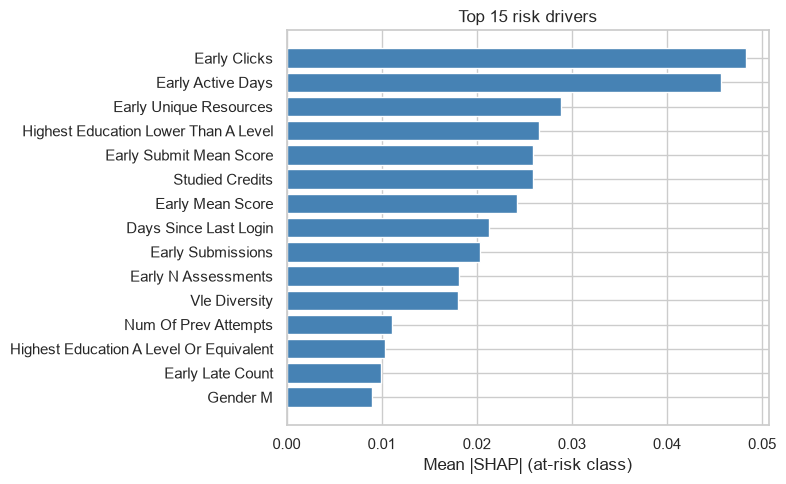

,rank,feature,feature_label,mean_abs_shap
0,1,early_clicks,Early Clicks,0.048349
1,2,early_active_days,Early Active Days,0.045687
2,3,early_unique_resources,Early Unique Resources,0.028824
3,4,highest_education_Lower Than A Level,Highest Education Lower Than A Level,0.026582
4,5,early_submit_mean_score,Early Submit Mean Score,0.025918
5,6,studied_credits,Studied Credits,0.025910
6,7,early_mean_score,Early Mean Score,0.024210
7,8,days_since_last_login,Days Since Last Login,0.021306
8,9,early_submissions,Early Submissions,0.020351
9,10,early_n_assessments,Early N Assessments,0.018167


In [4]:
shap_raw = pd.read_csv(OUTPUTS / "shap_feature_importance.csv")

shap_tableau = shap_raw.copy()
shap_tableau["feature_label"] = (
    shap_tableau["feature"].str.replace("_", " ", regex=False).str.title()
)
shap_tableau["rank"] = np.arange(1, len(shap_tableau) + 1)
shap_tableau = shap_tableau[["rank", "feature", "feature_label", "mean_abs_shap"]]

top_n = 15
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = shap_tableau.head(top_n).sort_values("mean_abs_shap")
ax.barh(plot_df["feature_label"], plot_df["mean_abs_shap"], color="steelblue")
ax.set_xlabel("Mean |SHAP| (at-risk class)")
ax.set_title(f"Top {top_n} risk drivers")
plt.tight_layout()
plt.show()

shap_tableau.head(top_n)

## 4. NLP + accessibility exports for Tableau

In [5]:
feedback_path = OUTPUTS / "feedback_classified.csv"
access_path = OUTPUTS / "accessibility_flags_by_course_week.csv"

if not feedback_path.exists() or not access_path.exists():
    raise FileNotFoundError(
        "Run notebook 04 first to create feedback_classified.csv and "
        "accessibility_flags_by_course_week.csv"
    )

feedback = pd.read_csv(feedback_path)
access_raw = pd.read_csv(access_path)

access_tableau = access_raw.rename(
    columns={
        "course_id": "code_module",
        "flag_rate": "accessibility_flag_rate",
    }
)

feedback_themes = (
    feedback.groupby(["course_id", "week", "predicted_category"], as_index=False)
    .agg(n_feedback=("feedback_id", "count"))
    .rename(columns={"course_id": "code_module"})
)

access_by_module = (
    access_tableau.groupby("code_module", as_index=False)
    .agg(
        n_feedback=("n_feedback", "sum"),
        n_accessibility_flags=("n_accessibility_flags", "sum"),
        avg_accessibility_flag_rate=("accessibility_flag_rate", "mean"),
    )
)
access_by_module["accessibility_flag_rate"] = (
    access_by_module["n_accessibility_flags"] / access_by_module["n_feedback"]
).round(3)

# Join module risk with synthetic accessibility signal for a combined dashboard slice
module_dashboard = risk_by_module.merge(
    access_by_module,
    on="code_module",
    how="left",
)
module_dashboard["n_feedback"] = module_dashboard["n_feedback"].fillna(0).astype(int)
module_dashboard["n_accessibility_flags"] = (
    module_dashboard["n_accessibility_flags"].fillna(0).astype(int)
)

print(f"Feedback rows: {len(feedback)}")
print(f"Accessibility course-week rows: {len(access_tableau)}")
module_dashboard.head(10)

Feedback rows: 60
Accessibility course-week rows: 39


,code_module,n_students,n_high_risk,n_medium_risk,n_low_risk,avg_risk_probability,actual_at_risk_rate,pct_high_risk,pct_medium_risk,pct_low_risk,n_feedback,n_accessibility_flags,avg_accessibility_flag_rate,accessibility_flag_rate
0,AAA,748,86,171,491,0.367897,0.290107,0.115,0.229,0.656,20,3,0.166600,0.15
1,BBB,7909,2525,1972,3412,0.521555,0.525351,0.319,0.249,0.431,20,3,0.200000,0.15
2,CCC,4434,2004,857,1573,0.547507,0.621561,0.452,0.193,0.355,0,0,NaN,NaN
3,DDD,6272,2268,1667,2337,0.532362,0.583865,0.362,0.266,0.373,2,0,0.000000,0.00
4,EEE,2934,785,711,1438,0.487226,0.437628,0.268,0.242,0.490,4,0,0.000000,0.00
5,FFF,7762,2188,1776,3798,0.477518,0.530018,0.282,0.229,0.489,6,0,0.000000,0.00
6,GGG,2534,681,993,860,0.504385,0.402526,0.269,0.392,0.339,8,2,0.285714,0.25


## 5. Export Tableau-ready CSVs

In [6]:
exports = {
    "tableau_student_risk_full.csv": risk_full,
    "tableau_risk_by_module.csv": risk_by_module,
    "tableau_risk_by_presentation.csv": risk_by_presentation,
    "tableau_shap_drivers.csv": shap_tableau,
    "tableau_accessibility_heatmap.csv": access_tableau,
    "tableau_feedback_themes.csv": feedback_themes,
    "tableau_module_risk_accessibility.csv": module_dashboard,
}

for filename, frame in exports.items():
    out = OUTPUTS / filename
    frame.to_csv(out, index=False)
    print(f"{filename:40s}  {len(frame):>6,} rows  ->  {out}")

print("\nTableau setup tips:")
print("- View 1: tableau_student_risk_full.csv -> risk_tier (color), code_module (filter)")
print("- View 2: tableau_shap_drivers.csv -> bar chart of feature_label vs mean_abs_shap")
print("- View 3: tableau_accessibility_heatmap.csv -> code_module x week, color = accessibility_flag_rate")

tableau_student_risk_full.csv             32,593 rows  ->  d:\ed_project\outputs\tableau_student_risk_full.csv
tableau_risk_by_module.csv                     7 rows  ->  d:\ed_project\outputs\tableau_risk_by_module.csv
tableau_risk_by_presentation.csv              22 rows  ->  d:\ed_project\outputs\tableau_risk_by_presentation.csv
tableau_shap_drivers.csv                      48 rows  ->  d:\ed_project\outputs\tableau_shap_drivers.csv
tableau_accessibility_heatmap.csv             39 rows  ->  d:\ed_project\outputs\tableau_accessibility_heatmap.csv
tableau_feedback_themes.csv                   57 rows  ->  d:\ed_project\outputs\tableau_feedback_themes.csv
tableau_module_risk_accessibility.csv          7 rows  ->  d:\ed_project\outputs\tableau_module_risk_accessibility.csv

Tableau setup tips:
- View 1: tableau_student_risk_full.csv -> risk_tier (color), code_module (filter)
- View 2: tableau_shap_drivers.csv -> bar chart of feature_label vs mean_abs_shap
- View 3: tableau_accessibility_